# 03 — Exploratory Data Analysis

Structured by business question, not by chart type. Every chart has a written
takeaway underneath it — a chart without an interpretation answers nothing.

Loads the feature tables saved by notebook 02. No cleaning or feature
engineering is repeated here.

## Business questions

1. **Revenue health** — how is monthly revenue trending, and is growth driven by
   new or returning customers?
2. **Concentration risk** — which products and countries drive revenue? Does 80/20 hold?
3. **Retention** — what share of customers buy twice, and how fast does each cohort decay?
4. **Customer value** — who is high-value, loyal, at risk, and how much revenue is at risk?
5. **Leakage** — how much revenue is lost to cancellations?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_parquet("../data/processed/retail_features.parquet")
orders = pd.read_parquet("../data/processed/orders.parquet")
customers = pd.read_parquet("../data/processed/customers.parquet")
cohorts = pd.read_parquet("../data/processed/cohorts.parquet")

sales = df[~df["is_cancelled"]]

df.shape, orders.shape, customers.shape, cohorts.shape

((1021128, 15), (39516, 7), (5852, 8), (36594, 11))

In [3]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

## Q1a - How is monthly revenue trending?

Revenue by calendar month, cancellations excluded.

**December 2011 is excluded from the chart.** The data stops on 9 December, so
that month covers 9 days rather than 31. Plotting it would show a 58% revenue
collapse that did not happen. 24 complete months remain.

In [4]:
monthly = sales.groupby("year_month")["Revenue"].sum()
monthly_full = monthly[monthly.index != "2011-12"]

monthly_full.round(2)

year_month
2009-12     797738.02
2010-01     612271.20
2010-02     537893.54
2010-03     761665.62
2010-04     646233.18
2010-05     643474.28
2010-06     696439.47
2010-07     632983.51
2010-08     674036.87
2010-09     869224.44
2010-10    1094357.68
2010-11    1429553.47
2010-12     775572.23
2011-01     670361.99
2011-02     507783.42
2011-03     689708.49
2011-04     515354.78
2011-05     739914.35
2011-06     737558.98
2011-07     688144.79
2011-08     724196.76
2011-09    1028313.80
2011-10    1103310.96
2011-11    1452112.69
Name: Revenue, dtype: float64

In [5]:
monthly_full.idxmax(), monthly_full.max(), monthly_full.idxmin(), monthly_full.min()

('2011-11', 1452112.69, '2011-02', 507783.42)

In [6]:
year_1 = monthly["2009-12":"2010-11"].sum()
year_2 = monthly["2010-12":"2011-11"].sum()

year_1.round(2), year_2.round(2), round(100 * (year_2 - year_1) / year_1, 1)

(np.float64(9395871.28), np.float64(9632333.24), np.float64(2.5))

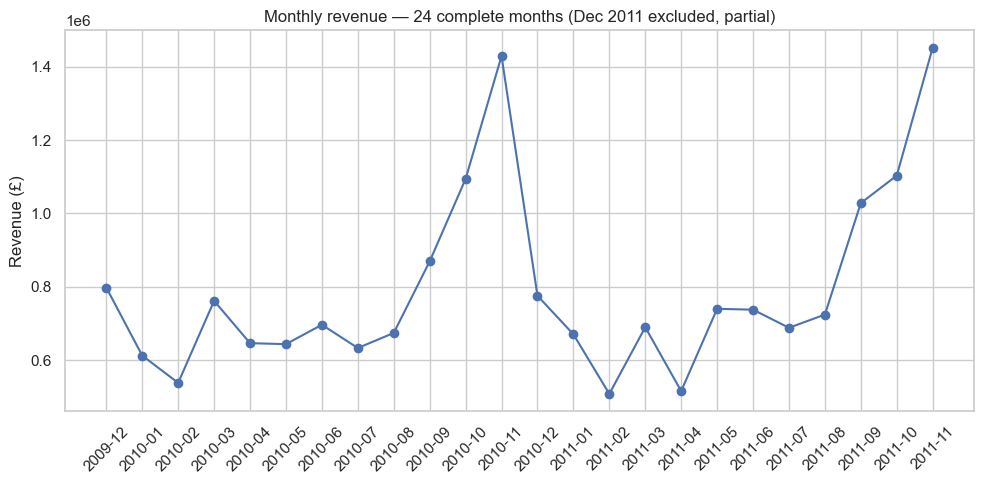

In [7]:
monthly_full.plot(kind="line", marker="o")

plt.title("Monthly revenue — 24 complete months (Dec 2011 excluded, partial)")
plt.ylabel("Revenue (£)")
plt.xlabel("")
plt.xticks(range(len(monthly_full)), monthly_full.index, rotation=45)
plt.tight_layout()
plt.show()

## Q1b — Is revenue driven by new or returning customers?

Each order is tagged from the cohort table: an order at `cohort_index == 0` is
that customer's first-ever purchase (**new**); any later order is **returning**.

This split covers identified customers only (the £17.07M cohort table), since a
customer with no ID can't be placed as new or returning. December 2011 is again
excluded as a partial month.

In [8]:
cohorts["customer_type"] = cohorts["cohort_index"].apply(
    lambda x: "New" if x == 0 else "Returning"
)

split = cohorts[cohorts["order_month"] != "2011-12"].pivot_table(
    index="order_month",
    columns="customer_type",
    values="order_value",
    aggfunc="sum",
).fillna(0)

split.round(2).head()

customer_type,New,Returning
order_month,,
2009-12,677916.07,0.00
2010-01,157879.40,375833.58
2010-02,166559.47,331378.10
2010-03,208717.31,457256.36
2010-04,122829.49,462297.94


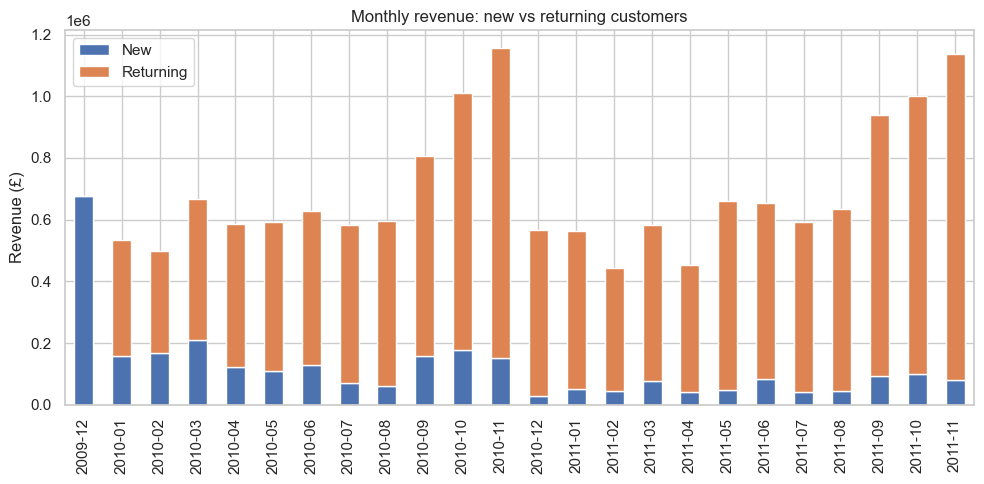

In [9]:
split.plot(kind="bar", stacked=True, color=["#4C72B0", "#DD8452"])

plt.title("Monthly revenue: new vs returning customers")
plt.ylabel("Revenue (£)")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

**Takeaway.** Returning customers generate **82.8% of identified revenue**
(£14.13M of £17.07M); new customers only 17%. New-customer revenue declines
over the two years while returning revenue sustains the total — which is why
headline revenue (Q1a) is flat: the business is retaining its base, not growing
it, and new acquisition has stalled.

This makes retention the primary lever. It also frames the rest of the analysis:
if returning customers *are* the business, then understanding which of them are
at risk (Days 12, 19–21) is where the revenue protection lies.

Caveat: December 2009 shows as 100% new by construction — it is the first month,
so no customer has a prior purchase. It is an edge-of-data artefact, not a real
all-new month.

In [10]:
type_totals = cohorts.groupby("customer_type")["order_value"].sum()
returning_share = 100 * type_totals["Returning"] / type_totals.sum()

type_totals.round(2), round(returning_share, 1)

(customer_type
 New           2935972.39
 Returning    14132595.58
 Name: order_value, dtype: float64,
 np.float64(82.8))

## Q2 — Which products and countries drive revenue? Does 80/20 hold?

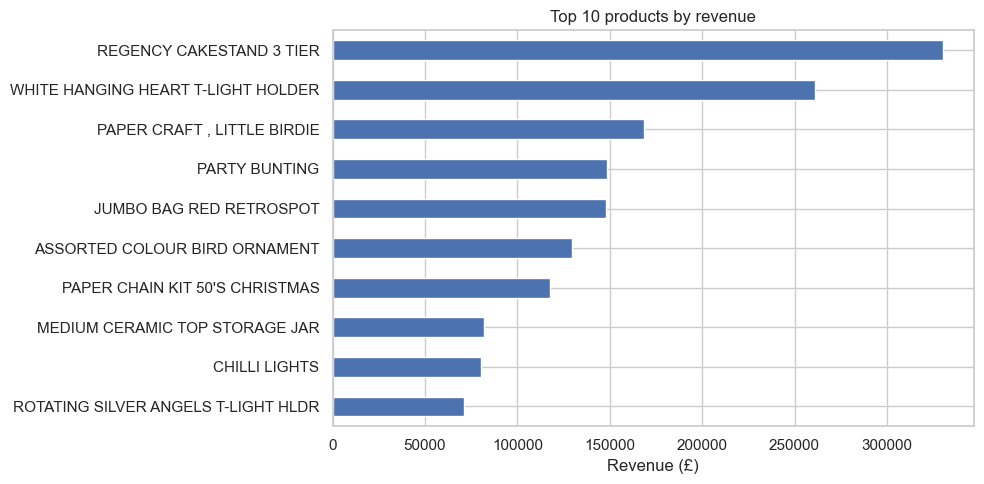

In [11]:
top_rev = sales.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)

top_rev.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Top 10 products by revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [12]:
top_units = sales.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_units

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77699
BROCADE RING PURSE                     70369
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48561
Name: Quantity, dtype: int64

**Takeaway.** Revenue leaders and volume leaders are different products. Regency Cakestand 3 Tier tops revenue at £330,590, but the best-seller by units is WW2 Gliders (106,139 units) — a low-price impulse item that does not appear in the revenue top 10. Only White Hanging Heart T-light Holder ranks high on both. The business has two distinct product roles: a few high-value SKUs that drive revenue, and cheap high-volume items that drive footfall.

In [13]:
country_rev = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
uk_share = 100 * country_rev["United Kingdom"] / country_rev.sum()

round(uk_share, 1), len(country_rev)

(np.float64(85.5), 43)

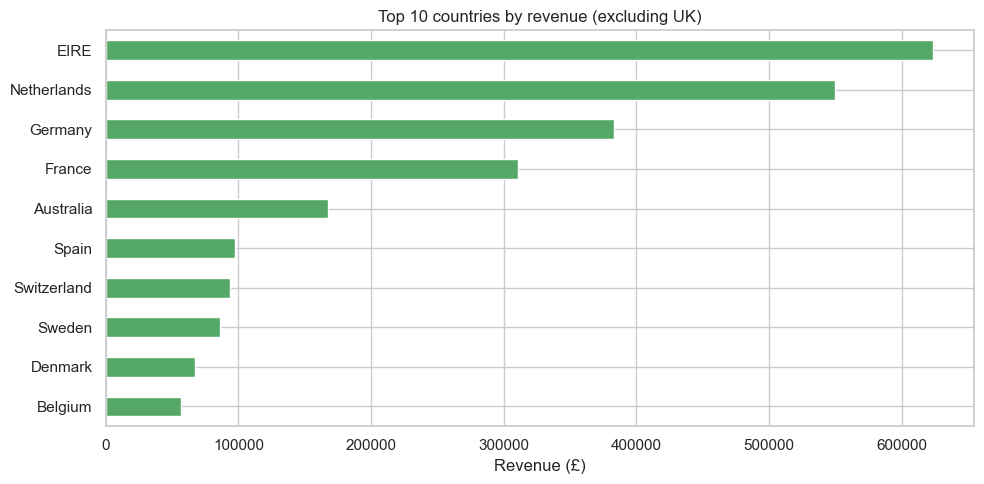

In [14]:
ex_uk = country_rev[country_rev.index != "United Kingdom"].head(10)

ex_uk.sort_values().plot(kind="barh", color="#55A868")
plt.title("Top 10 countries by revenue (excluding UK)")
plt.xlabel("Revenue (£)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Takeaway.** Revenue is overwhelmingly domestic: the **UK is 85.5%** of the total across 43 countries. The largest export markets are EIRE (£623K), the Netherlands (£550K), Germany (£383K) and France (£311K) — the top two are disproportionately large relative to population, consistent with wholesale/reseller accounts rather than retail. Geographic concentration is a risk: any UK-specific shock hits 85% of revenue at once.

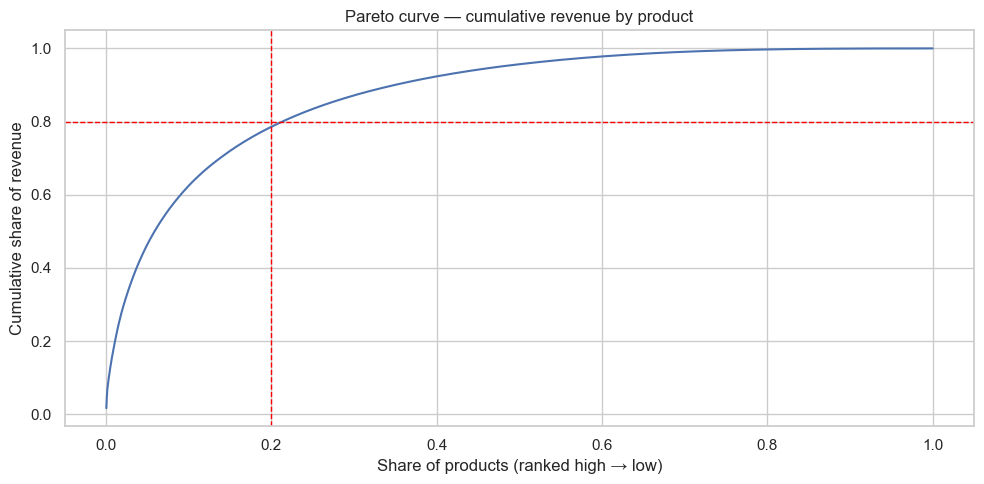

In [15]:
prod = sales.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False)
prod = prod[prod > 0]

cum_share = (prod.cumsum() / prod.sum()).values
prod_share = [i / len(prod) for i in range(1, len(prod) + 1)]

plt.plot(prod_share, cum_share)
plt.axhline(0.8, color="red", linestyle="--", linewidth=1)
plt.axvline(0.2, color="red", linestyle="--", linewidth=1)
plt.title("Pareto curve — cumulative revenue by product")
plt.xlabel("Share of products (ranked high → low)")
plt.ylabel("Cumulative share of revenue")
plt.tight_layout()
plt.show()

In [16]:
n_products = len(prod)
n_for_80 = (cum_share <= 0.8).sum() + 1

n_for_80, n_products, round(100 * n_for_80 / n_products, 1)

(np.int64(1040), 4878, np.float64(21.3))

**Takeaway.** The 80/20 rule holds almost exactly: **1,040 of 4,878 products (21.3%) generate 80% of revenue.** The red guide lines mark the 20%/80% point and the curve passes right through it. This is concentration risk worth flagging — the catalogue has ~3,800 products that together contribute only 20% of revenue, raising the question of whether the long tail earns its shelf and handling cost.

## Q3 — How many customers come back, and how fast do cohorts decay?

In [17]:
repeat_rate = (customers["n_orders"] >= 2).mean()
one_time_rate = (customers["n_orders"] == 1).mean()

round(100 * repeat_rate, 1), round(100 * one_time_rate, 1)

(np.float64(72.4), np.float64(27.6))

**Takeaway.** **72.4% of identified customers order at least twice**; 27.6% never return after their first purchase. A repeat rate this high reflects the wholesale/reseller character of the base — many customers are businesses restocking, not one-off gift buyers. The one-time quarter is still a meaningful leak: these customers were acquired but never activated into a second order.

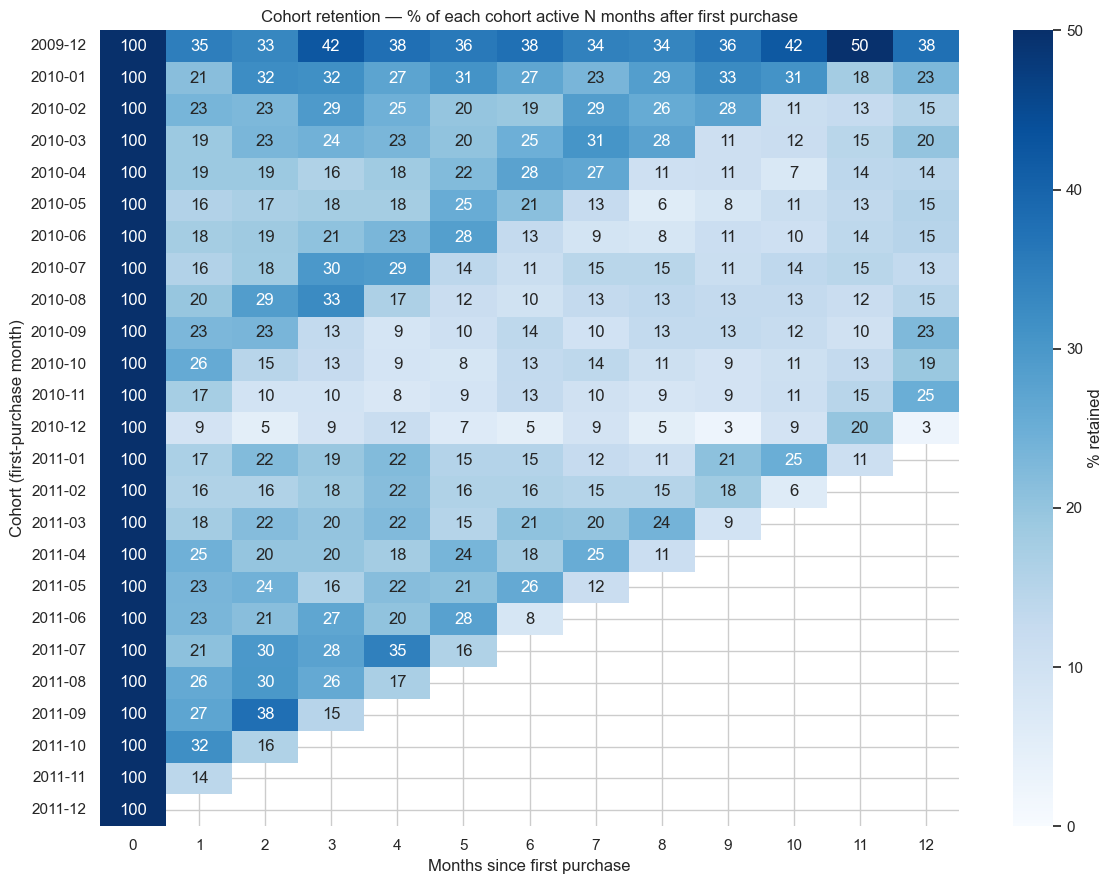

In [18]:
# distinct active customers per cohort (rows) and months-since-first (cols)
grid = cohorts.groupby(["cohort_month", "cohort_index"])["customer_id"].nunique().unstack()

# each row divided by its own month-0 size = % of the cohort still active
retention = grid.divide(grid[0], axis=0) * 100

# first 12 months keeps the heatmap legible
retention_12 = retention.loc[:, 0:12]

plt.figure(figsize=(12, 9))
sns.heatmap(retention_12, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=50,
            cbar_kws={"label": "% retained"})
plt.title("Cohort retention — % of each cohort active N months after first purchase")
plt.xlabel("Months since first purchase")
plt.ylabel("Cohort (first-purchase month)")
plt.tight_layout()
plt.show()

**Takeaway.** Retention drops steeply then flattens. Across cohorts, **month-1 retention averages ~20%** — four in five customers do not buy again in the very next month — but the curve then stabilises around 15–20% and holds for over a year, rather than decaying to zero. That plateau is the loyal core: once a customer survives the first month, they tend to stick.

Column 0 is 100% by definition (every customer is active in their joining month). The **December 2009 cohort reads higher throughout (~35% at month 1)** because it absorbs customers who were already established when the data begins — an edge-of-data artefact, not a genuinely better cohort. The empty lower-right triangle is expected: younger cohorts have not yet had the chance to age.

**Business implication:** the first month is where customers are lost. A retention intervention (a second-purchase nudge — a follow-up offer within 30 days) targets exactly the steepest part of the curve, where the largest number of customers churn.

## Q4 — How concentrated is customer value?

In [19]:
value_sorted = customers["total_revenue"].sort_values(ascending=False)
total_value = value_sorted.sum()

shares = {
    f"top {p:.0%}": round(100 * value_sorted.iloc[: int(len(value_sorted) * p)].sum() / total_value, 1)
    for p in [0.01, 0.05, 0.10, 0.20]
}
shares

{'top 1%': np.float64(31.9),
 'top 5%': np.float64(51.9),
 'top 10%': np.float64(63.9),
 'top 20%': np.float64(77.2)}

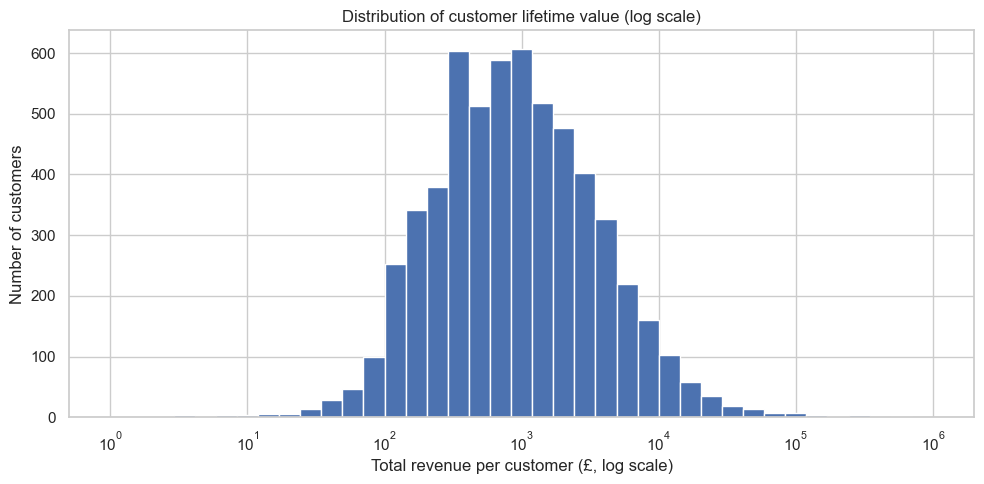

In [20]:
import numpy as np

plt.hist(customers["total_revenue"], bins=np.logspace(0, 6, 40),
         color="#4C72B0", edgecolor="white")
plt.xscale("log")
plt.title("Distribution of customer lifetime value (log scale)")
plt.xlabel("Total revenue per customer (£, log scale)")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

**Takeaway.** Customer value is highly concentrated: the **top 20% of customers generate 77% of revenue, and the top 1% (58 customers) alone generate 32%.** Median lifetime value is £856 against a mean of £2,917 — the gap confirms a long right tail of a few very large accounts (the wholesale buyers) sitting above a mass of small retail customers. On a log scale the distribution is roughly bell-shaped, i.e. lifetime value is approximately log-normal. **Implication:** losing a single top-percentile account is worth more than losing hundreds of typical ones — retention effort should be weighted by customer value, which is what the RFM segmentation (Days 19–21) operationalises.

## Q5 — How much revenue is lost to cancellations, and where is it concentrated?

In [21]:
gross = sales["Revenue"].sum()
cancelled = df[df["is_cancelled"]]["Revenue"].sum()
cancel_rate = 100 * abs(cancelled) / gross

round(cancelled, 2), round(cancel_rate, 1)

(np.float64(-716425.97), np.float64(3.6))

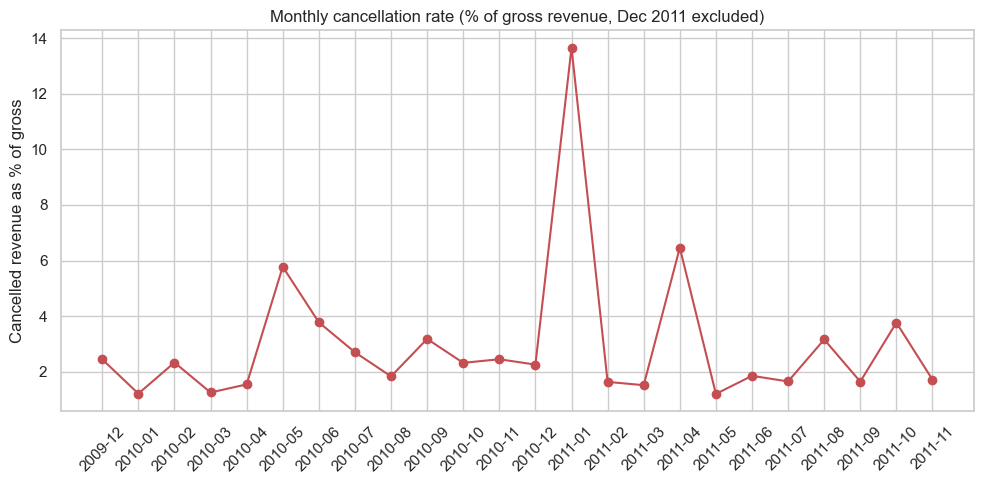

In [22]:
# monthly cancellation rate, partial final month excluded
monthly_gross = sales.groupby("year_month")["Revenue"].sum()
monthly_cancel = df[df["is_cancelled"]].groupby("year_month")["Revenue"].sum().abs()
cancel_by_month = (100 * monthly_cancel / monthly_gross)
cancel_by_month = cancel_by_month[cancel_by_month.index != "2011-12"]

cancel_by_month.plot(kind="line", marker="o", color="#C44E52")
plt.title("Monthly cancellation rate (% of gross revenue, Dec 2011 excluded)")
plt.ylabel("Cancelled revenue as % of gross")
plt.xlabel("")
plt.xticks(range(len(cancel_by_month)), cancel_by_month.index, rotation=45)
plt.tight_layout()
plt.show()

In [23]:
lost_by_product = (
    df[df["is_cancelled"]]
    .assign(lost=lambda d: -d["Revenue"])
    .groupby("Description")["lost"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
)
lost_by_product.round(2)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
MEDIUM CERAMIC TOP STORAGE JAR         77479.64
REGENCY CAKESTAND 3 TIER               16545.30
WHITE HANGING HEART T-LIGHT HOLDER      9387.10
COLOUR GLASS. STAR T-LIGHT HOLDER       6966.66
FAIRY CAKE FLANNEL ASSORTED COLOUR      6614.37
WHITE CHERRY LIGHTS                     6421.10
SET/4 WHITE RETRO STORAGE CUBES         5187.65
Name: lost, dtype: float64

**Takeaway.** Cancellations cost **£716,426 — 3.6% of gross revenue** — and the underlying monthly rate is low and stable (~2–4%), so this is normal returns activity, not a systemic problem. But the loss is extremely concentrated: **a single reversed order dominates it.** PAPER CRAFT, LITTLE BIRDIE accounts for £168,470 of cancelled value — an 80,995-unit order placed and then entirely cancelled in December 2011. That is the *same* order that appears as the #3 top-selling product in Q2, so its true net contribution is near zero, and it single-handedly pushes the December 2011 cancellation rate to 28% (why that month is excluded from the trend line).

**Implication:** headline cancellation loss is modest and well-controlled, but a small number of very large orders distort both revenue and cancellation figures. Large-order revenue should be treated as provisional until it clears — a data-quality point worth carrying into the dashboard so a single reversible order can't swing a KPI.

## Behavioural patterns — when do customers buy?

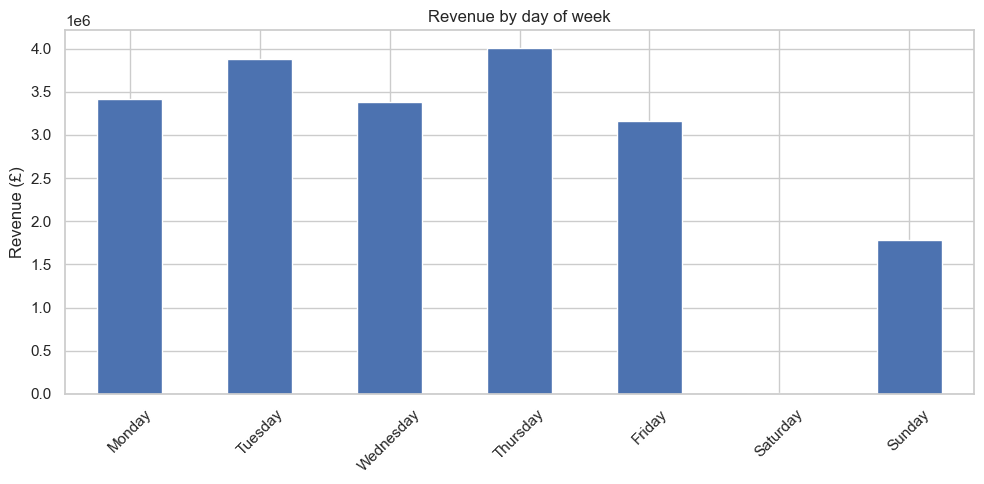

In [24]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
revenue_by_day = sales.groupby("day_of_week")["Revenue"].sum().reindex(day_order)

revenue_by_day.plot(kind="bar", color="#4C72B0")
plt.title("Revenue by day of week")
plt.ylabel("Revenue (£)")
plt.xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Takeaway.** Trade is a weekday business. Monday–Friday are all broadly comparable (£3.2–4.0M each), Sunday is roughly half a weekday, and **Saturday is effectively absent — just £9,803 across the entire two years, from only 400 transaction lines.** This is not missing data: the retailer does not process orders on Saturdays. The explicit day ordering (`reindex(day_order)`) matters here — `day_of_week` is text, so without it the bars would sort alphabetically and the weekday pattern would be unreadable.

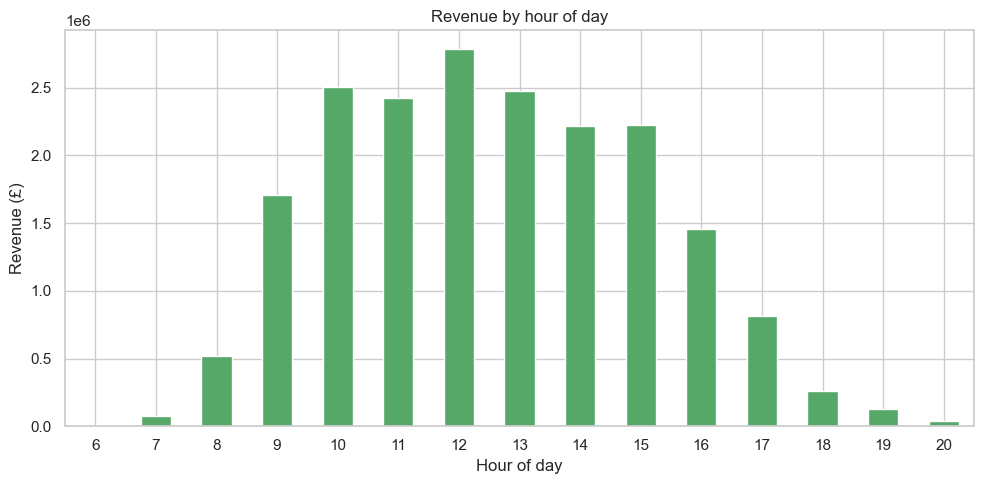

In [25]:
revenue_by_hour = sales.groupby("hour")["Revenue"].sum()

revenue_by_hour.plot(kind="bar", color="#55A868")
plt.title("Revenue by hour of day")
plt.ylabel("Revenue (£)")
plt.xlabel("Hour of day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Takeaway.** Purchasing is tightly clustered in office hours: revenue runs from ~07:00 to 20:00 and peaks at midday, with **74.5% of all revenue booked between 10:00 and 15:59.** The concentration in business hours reinforces the wholesale/reseller reading of the customer base — buyers are placing orders during their own working day, not browsing in the evening like typical consumer retail. **Implication for the business:** staffing, customer support and any flash-sale timing should target the 10:00–16:00 window, and there is essentially no evening or weekend demand to serve.

## EDA summary — the five questions answered

| # | Question | Headline finding |
|---|---|---|
| Q1 | Revenue health | Flat (+2.5% YoY); **83% of revenue from returning customers** — a retention story, not growth |
| Q2 | Concentration | UK = 85.5% of revenue; **21% of products drive 80%** (Pareto holds) |
| Q3 | Retention | 72% buy again, but **~80% of a cohort is lost after month 1**, then a loyal core plateaus |
| Q4 | Customer value | **Top 20% of customers = 77% of revenue**; value is log-normal with a wholesale tail |
| Q5 | Leakage | £716K (3.6%) lost to cancellations, but **concentrated in a single reversed £168K order** |

**The through-line:** this is a stable, retention-driven, highly concentrated business — concentrated in the UK, in a fifth of its products, in its top customers, and in a Q4 seasonal peak. The strategic lever is **protecting and growing the existing high-value base**, which is exactly what the segmentation in notebook 04 quantifies.